### Necessary Imports

In [ ]:
from astropy.table import Table, QTable
from astropy.io.votable import parse
import astropy.units as u
from matplotlib import pyplot as plt
import numpy as np
import os
import pandas as pd
import pathlib

#### Now we'll use the stored rcparams.txt file to format our figure

In [2]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

### Now let's read in all our good CNN predicted periods

In [3]:
reportable = pd.read_csv('reportable.csv', index_col='Unnamed: 0').rename(columns={'edr3_source_id':'EDR3'})
reportable['bp-rp'] = reportable['phot_bp_mean_mag']-reportable['phot_rp_mean_mag']
reportable['abs_g_mag'] = reportable['phot_g_mean_mag'] - 5*np.log10(1000/reportable['parallax']) + 5
reportable['frac'] = reportable['sigma']/reportable['period']

/Users/mschochet/anaconda3/envs/asassncnn/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


### And divide them into their subpopulations

In [4]:
cold = reportable[reportable['bp-rp'] >= 0.6]
hot = reportable[reportable['bp-rp'] < 0.6]

oscillators = cold[cold['abs_g_mag'] <= ((2*cold['bp-rp']) - 4)]
nonoscillators = cold[cold['abs_g_mag'] > ((2*cold['bp-rp']) - 4)]

subgiants = nonoscillators[nonoscillators['abs_g_mag'] < ((1.4*nonoscillators['bp-rp'])+2.8)]
ms = nonoscillators[nonoscillators['abs_g_mag'] >= ((1.4*nonoscillators['bp-rp'])+2.8)]

### For our oscillator population, we are interested in exploring whether our inferred periods are related to the oscillatory periods of a potential giant star

#### For each star in our sample, we have XGBoost surface gravity (as log(g)) and effective temperature. Using the asteroseismic relation:

$$
\frac{\nu_{\rm{max}}}{\nu_{\rm{max, \odot}}} = f_{\nu_{\rm{max}}} \frac{g}{g_{\odot}} (\frac{T_{eff}}{T_{eff, \odot}})^{-0.5}
$$

#### we can calculate an approximate $\nu_{max}$ by:

$$
f_{\nu_{\rm{max}}} = 1
$$
$$
\frac{T_{eff}}{T_{eff, \odot}} = \frac{T_{eff, XGBoost}}{5777 [K]}
$$
$$
\frac{g}{g_{\odot}} = \frac{10^{log(g)_{XGBoost}}}{10^{4.4.38}}
$$


#### which put all together gives us:

$$

\nu_{\rm{max}}= (\frac{T_{eff, XGBoost}}{5777 [K]})^{-0.5} * \frac{10^{log(g)_{XGBoost}}}{10^{4.43811496366}} * 86400
$$
$$
\nu_{\rm{max, \odot}} \approx 3090 \rm{MHz}
$$

#### Such that our x axis is graphed as:

$$

\frac{1}{\frac{\nu_{\rm{max}}}{\nu_{\rm{max, \odot}}}} [days]
$$

In [30]:
astropy_oscillators = QTable().from_pandas(oscillators)
astropy_oscillators = astropy_oscillators.filled(np.nan) 
astropy_oscillators['period'] = astropy_oscillators['period'] * u.day
astropy_oscillators['g_star'] = 10**(astropy_oscillators['logg_xgboost'])
astropy_oscillators['teff_xgboost'] =  astropy_oscillators['teff_xgboost']*u.Kelvin

sol_g = 10**(4.438)
sol_teff = 5772*u.Kelvin
sol_muhz = 3076*u.uHz

astropy_oscillators['nu'] = (((astropy_oscillators['g_star']/sol_g) * (astropy_oscillators['teff_xgboost']/sol_teff)**(-0.5))*sol_muhz).to(u.d**(-1))
astropy_oscillators['day'] = 1/astropy_oscillators['nu']
oscillators_final = astropy_oscillators.to_pandas()

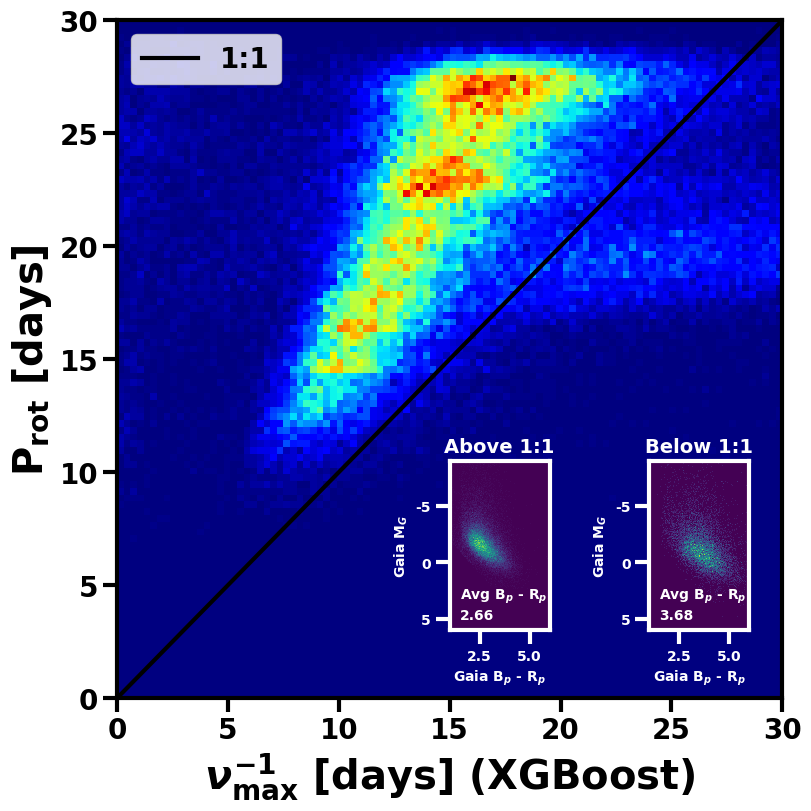

In [31]:
fig, axs = plt.subplots(1, 1, figsize=(8, 8), layout='constrained')
cm = plt.colormaps.get_cmap('Spectral')
axs.set(xlim=(0, 30), ylim=(0, 30)) 
axs.set_ylabel(r'P$_{\rm{rot}}$ [days]')
axs.set_xlabel(r'$\nu_{\rm{max}}^{-1}$ [days] (XGBoost)')

im = axs.hist2d('day', 'period', data=oscillators_final, bins=(100, 100), range=([0, 30], [0, 30]), cmap=plt.cm.jet, rasterized=True)

axs.plot([0, 30], [0, 30], "k", label="1:1", linewidth=3, rasterized=True)

oscillators_good = oscillators_final[oscillators_final['period'] > oscillators_final['day']]
oscillators_bad = oscillators_final[oscillators_final['period'] < oscillators_final['day']]

axin1 = axs.inset_axes([0.5, 0.1, 0.15, 0.25])
axin2 = axs.inset_axes([0.8, 0.1, 0.15, 0.25])

cmap = plt.cm.viridis_r
[ax.set_xlabel('Gaia B$_p$ - R$_p$', fontsize=10, color='white') for ax in [axin1, axin2]]
[ax.set_ylabel(f'Gaia M$_G$', fontsize=10, color='white') for ax in [axin1, axin2]]
[ax.set_xticks(ticks = [2.5, 5.0], labels=[2.5, 5.0], fontsize=10) for ax in [axin1, axin2]]
[ax.set_yticks(ticks = [-5, 0, 5], labels=[-5, 0, 5], fontsize=10) for ax in [axin1, axin2]]

axin1.hist2d('bp-rp', 'abs_g_mag',  data= oscillators_good,  bins=(200, 200), range=([1, 6], [-9, 6]), cmap=plt.cm.viridis, rasterized=True)
axin2.hist2d('bp-rp', 'abs_g_mag',  data= oscillators_bad, bins=(200, 200), range=([1, 6], [-9, 6]), cmap=plt.cm.viridis, rasterized=True)
axin1.invert_yaxis() 
axin2.invert_yaxis() 
axin1.set_title('Above 1:1', weight='bold', fontsize=14, color='white')
axin2.set_title('Below 1:1', weight='bold', fontsize=14, color='white')

for ax in [axin1, axin2]:
    ax.tick_params(color='white', labelcolor='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('white')


axin1.text(1.5, 5, f"Avg B$_p$ - R$_p$ \n{'%.2f' % np.median(oscillators_good['bp-rp'])}", fontsize=10, color='white', rasterized=True)
axin2.text(1.5, 5, f"Avg B$_p$ - R$_p$ \n{'%.2f' % np.median(oscillators_bad['bp-rp'])}", fontsize=10, color='white', rasterized=True)
plt.legend(facecolor='white', loc='upper left')
plt.savefig('oscillators_xgboost.pdf', dpi=300)
plt.show()